# Spatial Deconvolution
### SpatialDecon
**Author:** Diana Vera Cruz


## Goal

Spatial Deconvolution infers cell abundance per cell type in each segment, based on a reference matrix. This method does not incorporate the spatial context for a given segment, rather infers cell types abundances based on expression, and if nuclei counts are available, it can be used to adjust the cell type abundances.

## Steps:

You can start with a "NanoStringGeoMxSet" or a "Seurat" object.

In [2]:
out_dir = './GeoMx'

In [3]:
## cd /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2
##sbatch --mem=10G  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/geomx_env

library(tidyverse)
library(SpatialDecon)
library(GeomxTools)
library(ComplexHeatmap)

geomx = readRDS(file.path('/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/GeoMx/results', 'tidy_geomx_obj.rds'))

## Outdir -> set the results folder. 
out_dir = file.path(out_dir, 'results')
if(!dir.exists( out_dir )) dir.create( out_dir, recursive = T)

## Initial normalization: Q3, Upperquartile normalization.
geomx <- normalize(geomx, 
                     fromElt = "exprs",
                     norm_method = "quant", 
                     desiredQuantile = .75,
                     toElt = "q_norm")

## Add Assumed cell type: Combination of region + segment. 
protocolData(geomx)$celltype = with(sData(geomx),  
     case_when(segment == 'Geometric Segment' ~ 'Glomeruli', 
               segment == 'PanCK-' ~ 'Distal\nTubules', 
               TRUE ~ 'Proximal\nTubules'))

### 1. Calculate Background (Optional)

This requires the presence of Negative Probes in the dataset.

**Input** \* norm: Normalized expression matrix (Linear scale) \* probepool: Probeset names \* negnames: Negative control probeset names

In [4]:
## Calculate background for data-set: Based in Negative Control Probes. For each probeset, one value in negnames. 
##Check the negative control probes in the dataset, NegProbe prefix expected for most probesets. 
dplyr::select( fData(geomx), Module, TargetName) %>% filter(grepl('NegProbe', TargetName))

bg = derive_GeoMx_background(norm = geomx@assayData$q_norm,
                             probepool = fData(geomx)$Module,
                             negnames = c("NegProbe-WTX"))

,Module,TargetName
,<chr>,<chr>
NegProbe-WTX,Hs_R_NGS_WTA_v1.0,NegProbe-WTX


### 2. Cell Profile matrix

#### Predefined tables: Human/Mouse Atlas from Nanostring

In this case we will use the Kidney Dataset, which is the closest to our dataset.  
The profile matrix is (genes * cell_types) in size, and is the base for the deconvolution process. This methos is not spatially-aware, rather is completely based on expression patterns. 

In [5]:
## Obtained from https://github.com/Nanostring-Biostats/CellProfileLibrary/tree/master
human_kidney <- download_profile_matrix(species = "Human",
                                       age_group = "Adult", 
                                       matrixname = "Kidney_HCA")

dim(human_kidney)

[1] 16358    33

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



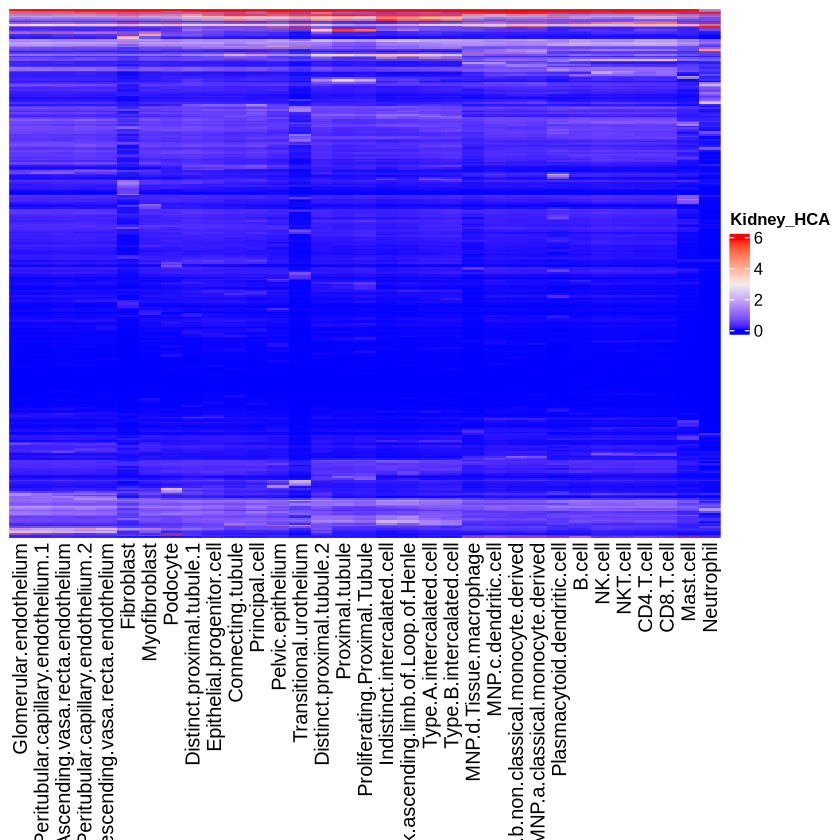

In [6]:
Heatmap(human_kidney, name = 'Kidney_HCA', #col = c('navy', 'orange'),
        show_column_dend = F, show_row_dend = F, use_raster = T, show_row_names = F, show_column_names = T)

#### Custom reference matrix.

You can also create a custom reference matrix derived from a set you annotated previously. The functions for this are included in [Bioconductor: SpatialDecon_vignette](https://bioconductor.org/packages/release/bioc/vignettes/SpatialDecon/inst/doc/SpatialDecon_vignette_NSCLC.html){.uri}

### Run deconvolution

In [7]:
res = runspatialdecon(
  object = geomx, 
  norm_elt = 'q_norm', 
  raw_elt = 'exprs',
  X = human_kidney, ## Reference matrix
  #cell_counts = sData(geomx)$nuclei ## Add if you have cell nuclei
)

beta_mx = res$beta

In [8]:
res = spatialdecon(
  norm = geomx@assayData$q_norm, 
  bg = bg,
  X = human_kidney, ## Reference matrix
  raw = geomx@assayData$exprs,
  cell_counts = sData(geomx)$nuclei 
)

beta_mx = res$beta
## Cell

###  Cell type proportions per AOI

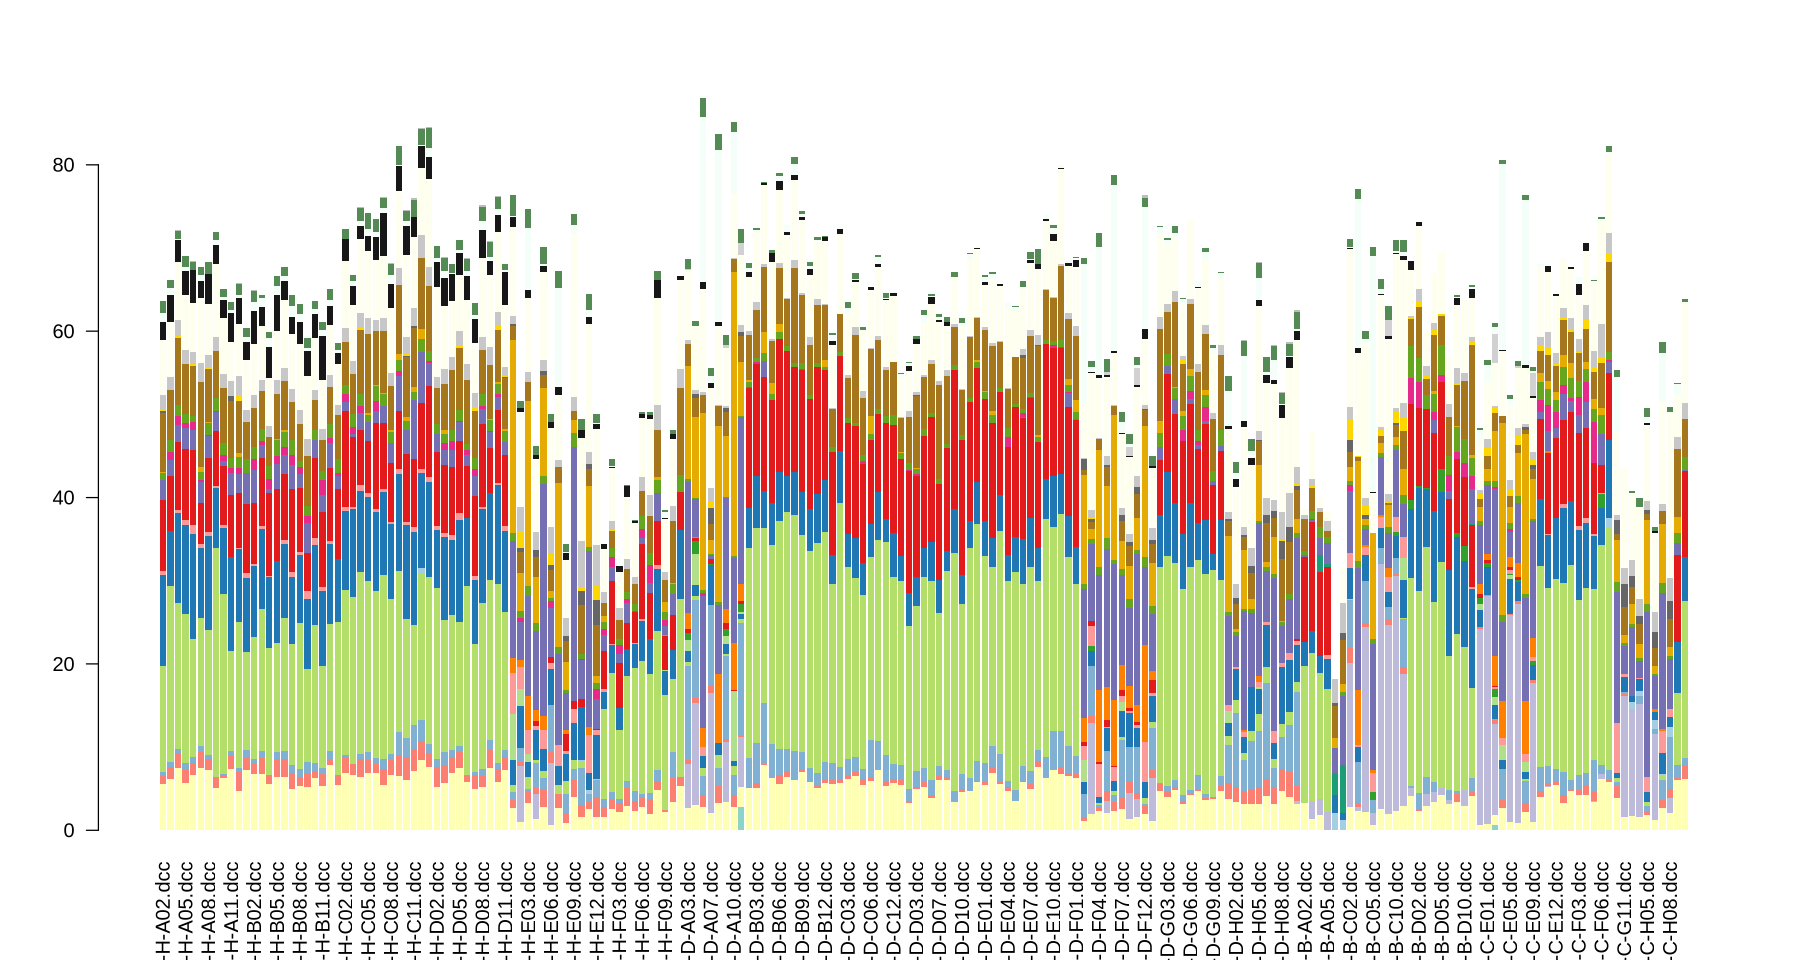

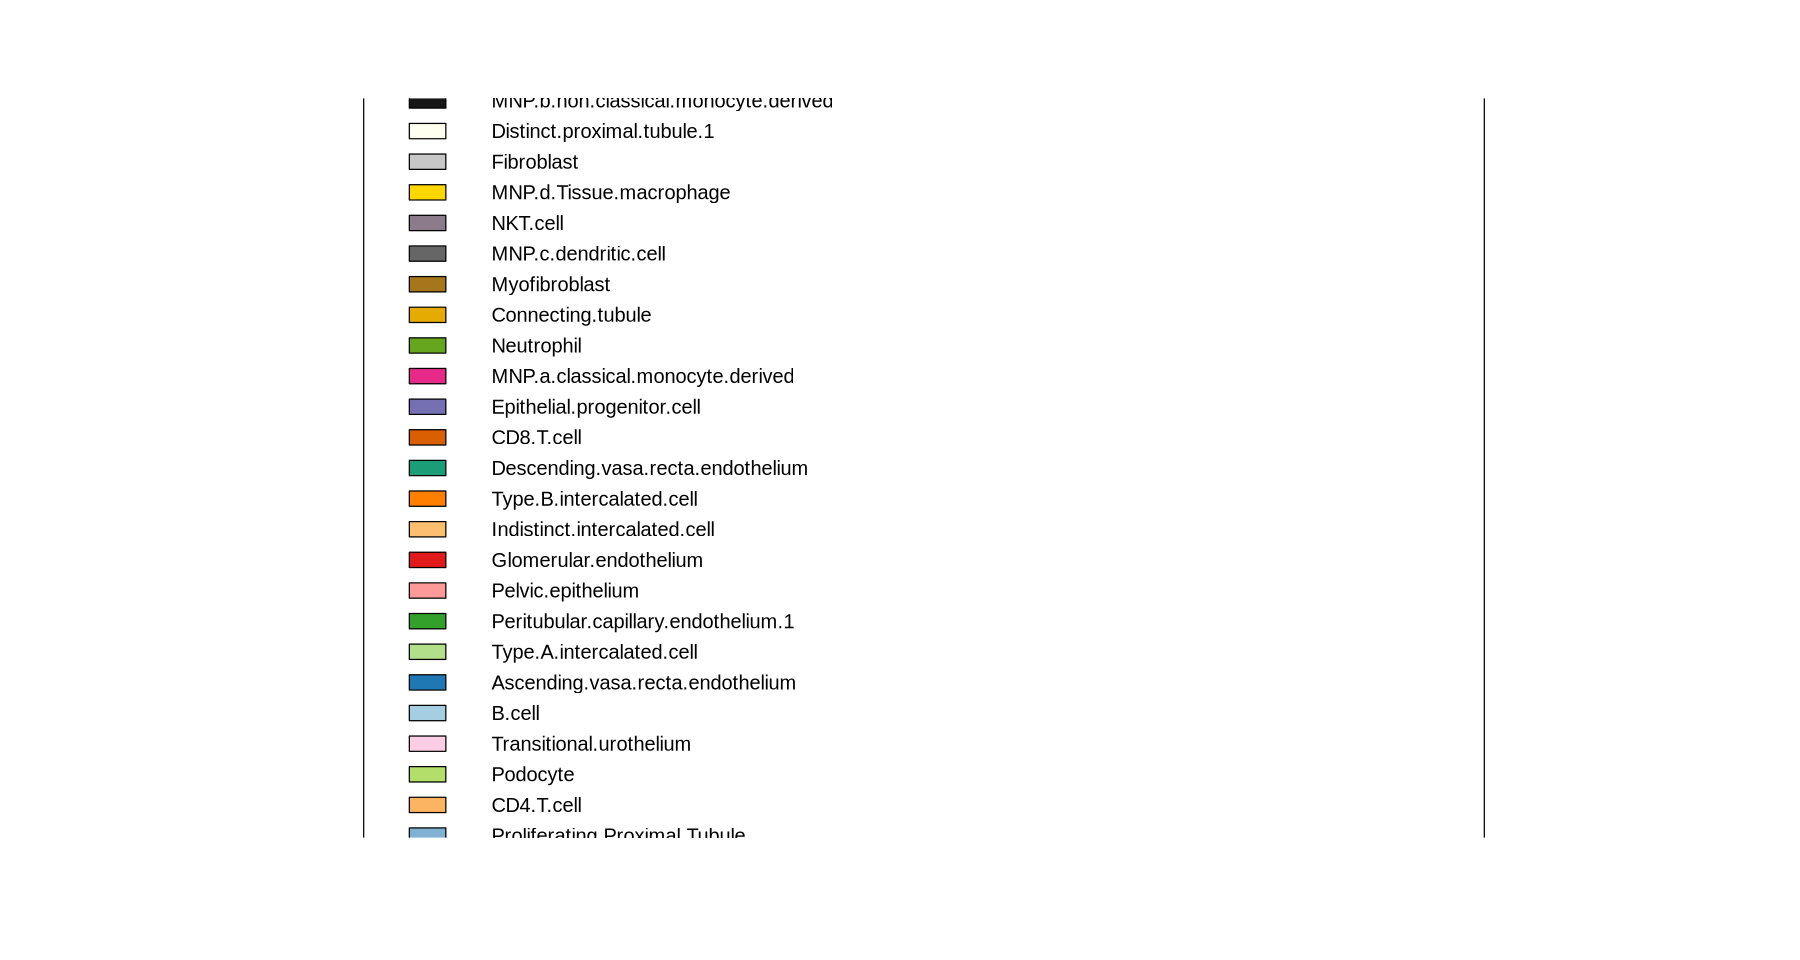

In [9]:
options(repr.plot.width = 15, repr.plot.height = 8)



TIL_barplot(mat = (beta_mx), draw_legend = T)

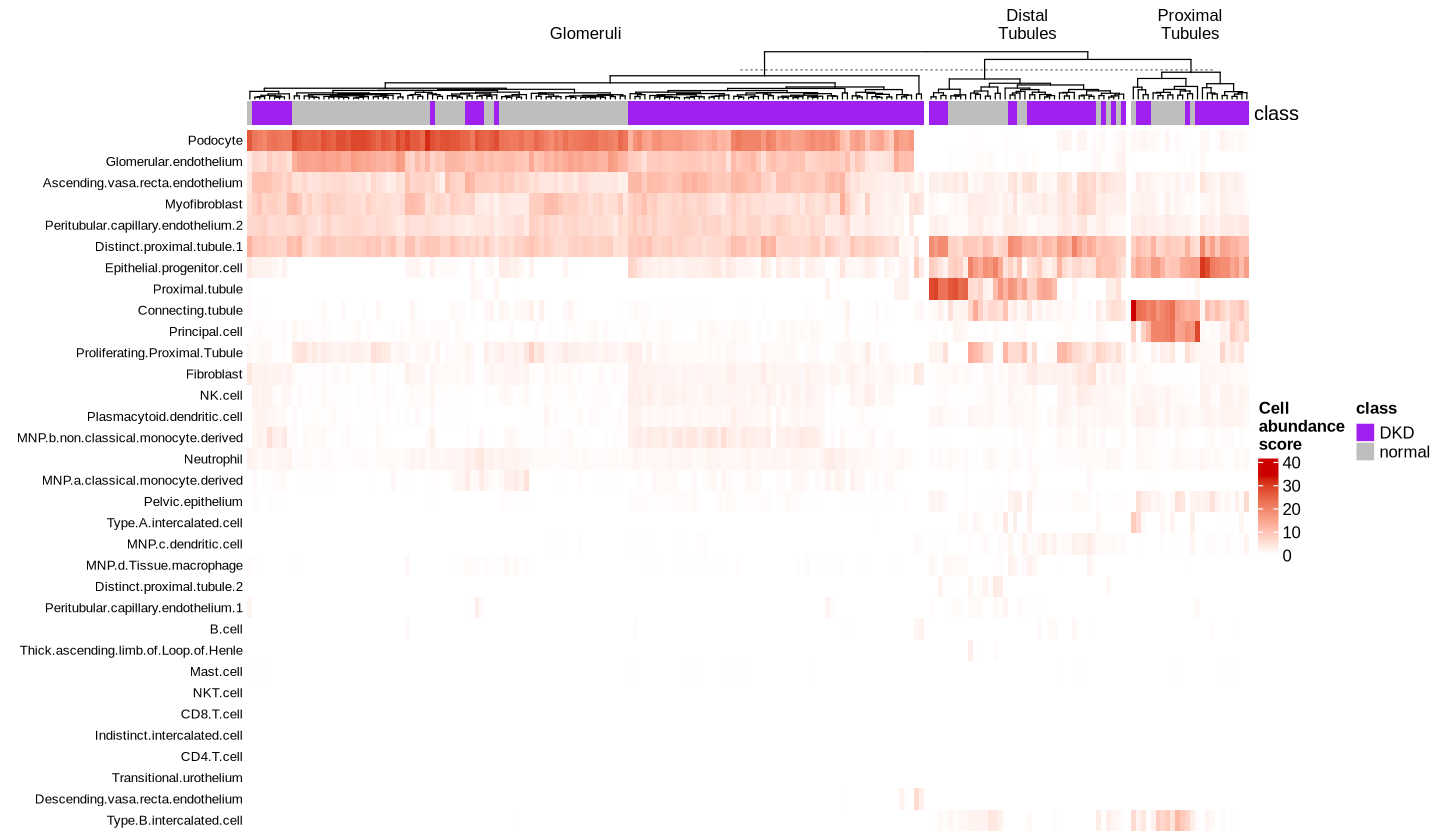

In [10]:
options(repr.plot.width = 12, repr.plot.height = 7)

Heatmap((beta_mx[,colSums(beta_mx) > 0]), show_column_names = F, show_row_dend = F,
        col = c('white', 'red3'), name = 'Cell\nabundance\nscore',
        show_parent_dend_line = T, row_names_side = 'left',
        #show_heatmap_legend = F, 
        row_names_gp = gpar(fontsize = 8), column_title_gp = gpar(fontsize = 10),
        top_annotation = HeatmapAnnotation(df = dplyr::select(sData(geomx), class), 
                                           col = list(class = c(DKD = 'purple', normal = 'grey'))),
        column_split = sData(geomx)$celltype)

In [11]:
## Write output table: 
write_tsv(as.data.frame(beta_mx) %>% rownames_to_column('CellType'), file.path(out_dir, 'SpatialDecon_CellAbundance.tsv'))